# Rabi Oscillations

## Overview

In this notebook we demonstrate Rabi oscillations using the circuit model of quantum computing.

We will:

1. Review the theoretical expression for excited-state probability.
2. Implement a single-qubit rotation $R_x(\theta)$.
3. Compare analytic and simulated probabilities.
4. Explore the effect of noise.
5. Estimate execution cost on quantum hardware.

The goal is to connect the physical concept of driven two-level dynamics with its circuit-level implementation.

## Physical Background

Rabi oscillations describe coherent population transfer in a driven two-level system.

In the circuit model, this corresponds to a rotation about the $x$-axis:

$$
R_x(\theta) = e^{-i \theta X / 2}
$$

If the system begins in $|0\rangle$, applying $R_x(\theta)$ yields

$$
P(|1\rangle) = \sin^2\left(\frac{\theta}{2}\right)
$$

Physically, we can interpret $\theta = \Omega t$, where:

- $\Omega$ is the Rabi frequency,
- $t$ is interaction time.

Sweeping $\theta$ therefore produces oscillatory population transfer.

## Setup

In [17]:
import numpy as np
import matplotlib.pyplot as plt

from braket.devices import LocalSimulator
from braket.tracking import Tracker
from braket.circuits import Circuit, ResultType

from braket.experimental.algorithms.rabi_oscillations import rabi_probability, rabi_circuit


tracker = Tracker().start()  # to track Braket costs

## Constructing the Circuit

We generate a single-qubit circuit implementing $R_x(\theta)$.

In [ ]:
theta_example = np.pi / 3
circ = rabi_circuit(theta_example)
print(circ)


T  : │     0      │
      ┌──────────┐ 
q0 : ─┤ Rx(1.05) ├─
      └──────────┘ 
T  : │     0      │
T  : │     0      │
      ┌──────────┐ 
q0 : ─┤ Rx(1.05) ├─
      └──────────┘ 
T  : │     0      │


## Sweeping the Rotation Angle

We vary $\theta$ from $0$ to $2\pi$ and compute the expected analytic probability.

In [19]:
# Sweep angles from 0 to 2π
thetas = np.linspace(0, 2 * np.pi, 101)

# Analytic prediction
p1_analytic = np.array([rabi_probability(theta) for theta in thetas])

## Ideal Simulation (Exact Probability)

Using the simulator in analytic mode (`shots=0`), we compute the exact excited-state probability.

In [20]:
device = LocalSimulator()

def p1_from_result_type(theta: float) -> float:
    circ = rabi_circuit(theta)
    circ.add_result_type(ResultType.Probability(target=[0]))
    task = device.run(circ, shots=0)  # analytic mode
    result = task.result()
    probs = result.result_types[0].value  # [P(|0>), P(|1>)]
    return float(probs[1])

p1_sim_exact = np.array([p1_from_result_type(theta) for theta in thetas])

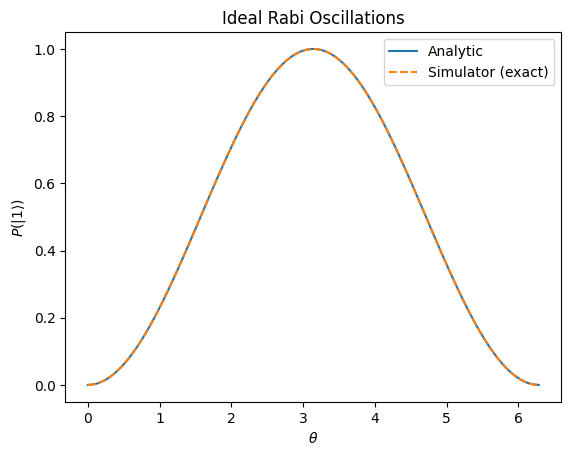

In [6]:
plt.figure()
plt.plot(thetas, p1_analytic, label="Analytic")
plt.plot(thetas, p1_sim_exact, linestyle="--", label="Simulator (exact)")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$P(|1\rangle)$")
plt.title("Ideal Rabi Oscillations")
plt.legend()
plt.show()

### Interpretation

The simulator result matches the analytic curve exactly.

This confirms that the circuit correctly implements the rotation $R_x(\theta)$ and reproduces ideal Rabi oscillations.

## Sampled Simulation (Finite Shots)

In practice, measurements are sampled. We now estimate the probability using a finite number of shots.

In [21]:
def p1_from_sampling(theta: float, shots: int = 1000) -> float:
    circ = rabi_circuit(theta)
    task = device.run(circ, shots=shots)
    result = task.result()
    counts = result.measurement_counts  # dict like {"0": n0, "1": n1}
    n1 = counts.get("1", 0)
    return n1 / shots

shots = 1000
p1_sim_sampled = np.array([p1_from_sampling(theta, shots=shots) for theta in thetas])

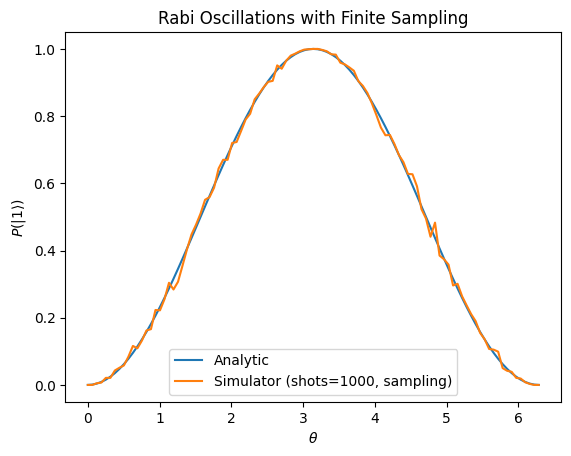

In [22]:
plt.figure()
plt.plot(thetas, p1_analytic, label="Analytic")
plt.plot(thetas, p1_sim_sampled, label=f"Simulator (shots={shots}, sampling)")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$P(|1\rangle)$")
plt.title("Rabi Oscillations with Finite Sampling")
plt.legend()
plt.show()

### Interpretation

Finite sampling introduces statistical fluctuations.  
As the number of shots increases, the sampled curve converges to the analytic prediction.

## Measurement Statistics at a Specific Angle

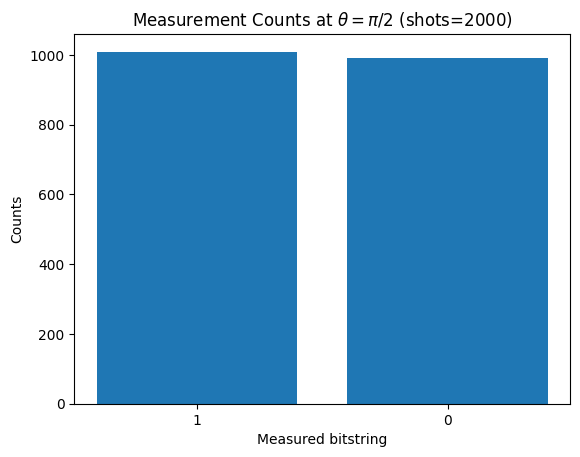

In [25]:
theta_hist = np.pi / 2
shots_hist = 2000

result = device.run(rabi_circuit(theta_hist), shots=shots_hist).result()
counts = result.measurement_counts

plt.figure()
plt.bar(list(counts.keys()), list(counts.values()))
plt.xlabel("Measured bitstring")
plt.ylabel("Counts")
plt.title(rf"Measurement Counts at $\theta=\pi/2$ (shots={shots_hist})")
plt.show()

### Interpretation

At $\theta = \pi/2$, the analytic prediction gives

$$
P(|1\rangle) = \sin^2\left(\frac{\pi}{4}\right) = \frac{1}{2}.
$$

This means the system is in an equal superposition of $|0\rangle$ and $|1\rangle$.

The histogram shows approximately equal counts for the two measurement outcomes.
Small deviations from perfect balance arise from finite sampling statistics.

As the number of shots increases, the observed distribution converges to the theoretical 50/50 split.

## Resource Usage and Cost Tracking

Amazon Braket provides a built-in task tracker that estimates the cost of simulator and QPU tasks based on actual execution.

Below, we display:

- A summary of tasks executed in this notebook  
- The estimated total cost based on those tasks  

Note: These values are estimates and depend on actual device usage and current pricing.

In [23]:
print("Task Summary")
print(f"{tracker.quantum_tasks_statistics()} \n")
print(
    f"Estimated cost to run this example: {tracker.qpu_tasks_cost() + tracker.simulator_tasks_cost():.2f} USD"
)

Task Summary
{} 

Estimated cost to run this example: 0.00 USD


### Interpretation

For local simulations, the estimated cost is typically zero or negligible.

If executed on a QPU, costs would depend on:

- The number of tasks submitted  
- The number of measurement shots  
- The selected hardware provider  

Always consult the official Amazon Braket pricing page for current rates.

In [26]:
tracker.stop()